In [1]:
print("Hello, World!")

Hello, World!


In [42]:
import os
import requests
import pandas as pd
from typing import List, Dict, Any
from matplotlib import pyplot as plt
import seaborn as sns

In [114]:
def _get_response_prices(date:str, headers:dict) -> Dict[str, Any]:
    resp = requests.get(
        "https://api.jquants.com/v2/equities/bars/daily",
        params  = {"date": date},
        headers = headers,
    )
    return resp.json()['data']

In [113]:
def _get_response_codes(date:str, headers:dict) -> Dict[str, Any]:
    resp = requests.get(
        "https://api.jquants.com/v2/equities/master",
        params  = {"date": date},
        headers = headers,
    )
    return resp.json()['data']

In [119]:
api_key = os.getenv('jq_api_key')
resp_prices = _get_response_prices("2024-06-01", headers = {"x-api-key": api_key})
resp_codes = _get_response_codes("2024-06-01", headers = {"x-api-key": api_key})

In [116]:
len(resp_prices), len(resp_codes)

(4358, 4358)

In [40]:
df = pd.DataFrame.from_records(resp)
df.head(5)

,Date,Code,O,H,L,C,UL,LL,Vo,Va,...,AC,AUL,ALL,AVo,AVa,AAdjO,AAdjH,AAdjL,AAdjC,AAdjVo
0,2013-01-04,86970,3740.0,4010.0,3740.0,3885.0,0,0,2113700.0,8.082686e+09,...,3885.0,0,0,719000.0,2.742410e+09,192.8,194.8,187.5,194.3,14380000.0
1,2013-01-07,86970,3945.0,3955.0,3850.0,3950.0,0,0,1574500.0,6.140398e+09,...,3950.0,0,0,796000.0,3.111950e+09,194.3,197.8,194.3,197.5,15920000.0
2,2013-01-08,86970,3950.0,3950.0,3870.0,3930.0,0,0,403000.0,1.579888e+09,...,3930.0,0,0,167000.0,6.569775e+08,197.3,197.5,196.0,196.5,3340000.0
3,2013-01-09,86970,3900.0,3940.0,3900.0,3925.0,0,0,193000.0,7.566560e+08,...,3925.0,0,0,84800.0,3.326965e+08,195.5,196.5,195.5,196.3,1696000.0
4,2013-01-10,86970,3925.0,4100.0,3925.0,4085.0,0,0,1109800.0,4.462056e+09,...,4085.0,0,0,603300.0,2.442026e+09,200.8,205.0,200.0,204.3,12066000.0


In [106]:
drop_cols = ['O', 'H', 'L', 'C', 'Vo', 'AdjO', 'AdjH', 'AdjL', 'MO', 'MH', 'ML', 'MVa','AAdjO', 'AAdjH', 'AAdjL', 'AAdjC', 'AAdjVo', 'AO', 'AH', 'AL', 'MAdjO', 'MAdjH', 'MAdjC', 'MAdjL', 'MAdjVo', 'UL', 'MUL', 'MLL', 'LL', 'AUL', 'ALL', 'MC', 'AC', 'AVo', 'MVo', 'AVa']
tmp_df = df.drop(columns=drop_cols)
# tmp_df[['MUL', 'MLL', 'LL', 'AUL', 'ALL']] = tmp_df[['MUL', 'MLL', 'LL', 'AUL', 'ALL']].astype('float')

In [107]:
df_corr = tmp_df.iloc[:, 2:].corr(method='pearson')

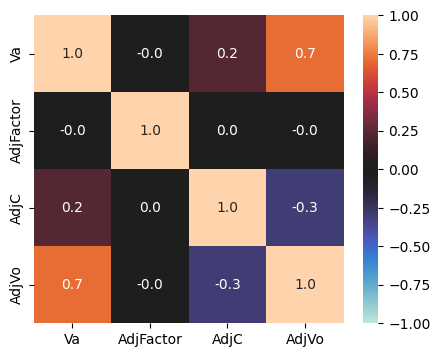

In [108]:
plt.figure(figsize=(5, 4))
sns.heatmap(df_corr,
            vmin=-1.0,
            vmax=1.0,
            center=0,
            annot=True, # True:格子の中に値を表示
            fmt='.1f',
            xticklabels=df_corr.columns.values,
            yticklabels=df_corr.columns.values
           )
plt.show()

In [109]:
tmp_df.head(5)

,Date,Code,Va,AdjFactor,AdjC,AdjVo
0,2013-01-04,86970,8.082686e+09,1.0,194.3,42274000.0
1,2013-01-07,86970,6.140398e+09,1.0,197.5,31490000.0
2,2013-01-08,86970,1.579888e+09,1.0,196.5,8060000.0
3,2013-01-09,86970,7.566560e+08,1.0,196.3,3860000.0
4,2013-01-10,86970,4.462056e+09,1.0,204.3,22196000.0
